In [45]:
!pip install tensorflow


In [46]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [47]:
## import some basic libararies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [48]:
dataset =pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [49]:
## divide dataset into dependent and independent featues

X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [50]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [51]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [52]:
## feature engineering

# Reinitialize X from dataset to ensure 'Geography' and 'Gender' are present
# This step is crucial because X might have been modified in previous cells
## X = dataset.iloc[:,3:13]

## one hot encoded countries where present there 1 else 0
geography = pd.get_dummies(X['Geography'],drop_first=True).astype(int)
gender = pd.get_dummies(X['Gender'],drop_first=True).astype(int)

# Drop original 'Geography' and 'Gender' columns from X
X = X.drop(['Geography','Gender'],axis=1)

# Concatenate these new variables with X
X = pd.concat([X,geography,gender], axis=1)

In [54]:
##concatenate these variables with dataframe
## X.drop(['Geography','Gender'],axis=1)

In [55]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [ ]:
## pd.concat([X,geography,gender], axis=1)

In [56]:
##splitting the dataset into train and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=0)

In [57]:
## feature scaling
##we use standard scalar when our data moves between 0 & 1 or near a mean value

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [58]:
X_train.shape

(8000, 11)

In [59]:
## Part 2 create ANN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [60]:
## initialize ANN

classifier = Sequential()

In [64]:
##Adding the input layer
## relu activation func will be applied to next layer
classifier.add(Dense(units=11,activation='relu'))

In [65]:
## adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))

In [66]:
##adding second hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [67]:
##Adding output layer
classifier.add(Dense(1,activation='sigmoid'))

In [73]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [75]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [76]:
##Early Stopping
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [77]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8647 - loss: 0.3313 - val_accuracy: 0.8519 - val_loss: 0.3621
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8698 - loss: 0.3292 - val_accuracy: 0.8535 - val_loss: 0.3553
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8681 - loss: 0.3268 - val_accuracy: 0.8527 - val_loss: 0.3775
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8668 - loss: 0.3301 - val_accuracy: 0.8504 - val_loss: 0.3639
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8683 - loss: 0.3263 - val_accuracy: 0.8504 - val_loss: 0.3967
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8696 - loss: 0.3254 - val_accuracy: 0.8565 - val_loss: 0.3584
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8688 - loss: 0.3269 - val_accuracy: 0.8595 - val_loss: 0.3604
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8664 - loss: 0.3265 - 

In [79]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

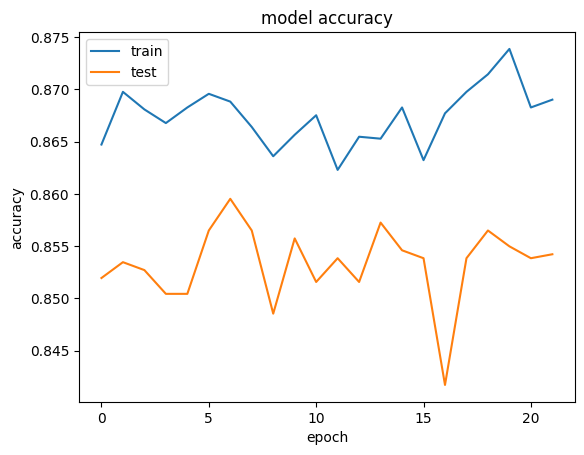

In [80]:
#summary history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

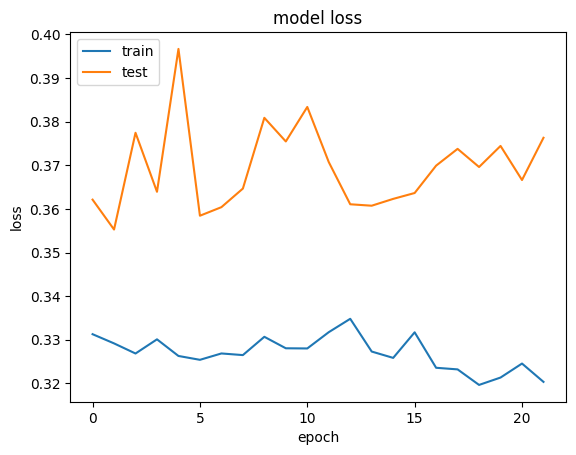

In [81]:
#summary history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [82]:
## part 3 making predictions and evaluating the model

#predicting the test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [83]:
## make confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1495,  100],
       [ 189,  216]])

In [84]:
##calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)
score

0.8555

In [85]:
## get the weights
classifier.get_weights()

[array([[ 0.15356143,  0.98778737,  2.1017575 , -1.3553277 ,  0.11111129,
          0.5447777 , -0.8959008 , -0.09735691, -0.2104791 ,  1.1190183 ,
          0.36895502],
        [ 1.5339711 , -5.2541537 , -2.266391  , -1.3484458 , -4.069052  ,
         -0.32949334, -3.9365962 ,  0.4649092 , -2.8005538 , -0.13552329,
         -0.00661941],
        [ 0.35661203,  0.4588651 , -0.70835453, -0.16537757,  0.38069645,
          2.358958  , -0.58857983,  0.2480779 , -0.8473193 , -0.15266804,
          0.33974162],
        [-2.039005  ,  0.14741272, -2.476866  , -1.6833551 , -0.24359782,
         -3.1123664 , -0.9131509 ,  0.48553032, -0.82531744,  1.3525908 ,
         -4.1321597 ],
        [ 0.25811872,  0.4046068 , -0.41088292, -2.1927252 ,  0.2961297 ,
         -0.17098811,  1.2214458 ,  4.154491  , -1.501196  , -0.6163251 ,
         -4.662226  ],
        [ 0.04580976, -0.89928025, -0.9037469 , -0.8407944 ,  0.23739341,
         -1.1490504 , -1.1534154 , -0.0677092 ,  1.506357  , -2.0748343